# Creating a sample of M stars between 50 and 200pc

Benjamin Pennell

--

Max Planck Institut für Astronomie, Heidelberg

---

In [1]:
from utils.dependencies import *;

/home/bepennell/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import h5py
import pyvo
from astroquery.gaia import Gaia
import matplotlib.patheffects as pe

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [3]:
def print_table(table, label=None):
    rates = [len(table[table["solution_type"] == soltype])/len(table)*100 for soltype in [0,5,7,9,12]]
    grid = [
        rates,
        [int(grp/100*len(table)) for grp in rates]
    ]
    row_labels = ["Rate (%)", "Counts"]
    col_labels = ["low RUWE", "high RUWE", "Acceleration", "Jerk", "Full Orbit"]
    df = pd.DataFrame(grid, index=row_labels, columns=col_labels)
    displaydf = df.style.format(
        "{:.0f}",
        subset=pd.IndexSlice["Counts", :]
    ).format(
        "{:.2f}",
        subset=pd.IndexSlice["Rate (%)", :]
    )
    
    if label is not None:
        displaydf.set_caption(label)
    
    display(displaydf)

## Select objects

In [4]:
msms = h5py.File("../BigData/msms_36m_v0.hdf5", "r")

In [94]:
msms["table"]["columns"].keys()

<KeysViewHDF5 ['E_binary', 'E_single', 'MG_prim', 'MG_second', 'b_r_prim', 'b_r_second', 'bp_rp', 'chi2_diff_mh_mass', 'chi2_mass_mh', 'chi2_mass_mh_binary', 'dec', 'e_E_binary', 'e_E_single', 'e_m1_binary', 'e_mass_single', 'e_mh_binary', 'e_mh_single', 'e_q_binary', 'fit_status_binary', 'fit_status_single', 'fit_success_binary', 'fit_success_single', 'flag_extrap_m2', 'flux_ratio_mean', 'flux_ratio_std', 'm1_binary', 'm2_binary', 'mass_single', 'mh_binary', 'mh_single', 'parallax', 'parallax_error', 'phot_g_mean_mag', 'predicted_class', 'q_binary', 'ra', 'radial_velocity', 'radial_velocity_error', 'source_id']>

In [40]:
new_table = Table()

In [41]:
labels = ["source_id", "parallax", "ra", "dec", "phot_g_mean_mag", "mass_single", "m1_binary", "m2_binary", "predicted_class", "bp_rp", "mh_single", "q_binary", "flux_ratio_mean", "flux_ratio_std", "chi2_mass_mh", "chi2_mass_mh_binary", "chi2_diff_mh_mass", "fit_success_single", "fit_success_binary"]
for label in labels:
    new_table.add_column(np.array(msms["table"]["columns"][label]["data"]), name=label)

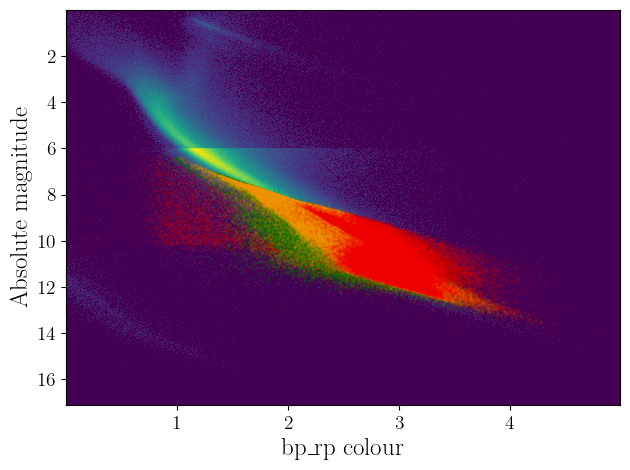

In [16]:
bp_rp = new_table["bp_rp"]
parallax = new_table["parallax"]
gmag = new_table["phot_g_mean_mag"]
absolute_magnitudes = gmag + 5 * np.log10(parallax) - 10


plt.hist2d(bp_rp[::5], absolute_magnitudes[::5], bins=1000, norm=matplotlib.colors.PowerNorm(0.4));
plt.ylabel("Absolute magnitude");
plt.xlabel("bp_rp colour");
plt.ylim(bottom=np.max(absolute_magnitudes), top=np.min(absolute_magnitudes));
plt.xlim([np.min(bp_rp), np.max(bp_rp)]);

crap_table = working_table[working_table["predicted_class"] == 0]
bp_rp = crap_table["bp_rp"]
parallax = crap_table["parallax"]
gmag = crap_table["phot_g_mean_mag"]
absolute_magnitudes = gmag + 5 * np.log10(parallax) - 10

plt.scatter(bp_rp, absolute_magnitudes, s=1, color="green", alpha=0.1)

crap_table = working_table[working_table["predicted_class"] == 1]
bp_rp = crap_table["bp_rp"]
parallax = crap_table["parallax"]
gmag = crap_table["phot_g_mean_mag"]
absolute_magnitudes = gmag + 5 * np.log10(parallax) - 10

plt.scatter(bp_rp, absolute_magnitudes, s=1, color="orange", alpha=0.05)

crap_table = working_table[working_table["predicted_class"] < 0]
bp_rp = crap_table["bp_rp"]
parallax = crap_table["parallax"]
gmag = crap_table["phot_g_mean_mag"]
absolute_magnitudes = gmag + 5 * np.log10(parallax) - 10

plt.scatter(bp_rp, absolute_magnitudes, s=1, color="red", alpha=0.05)

plt.tight_layout()

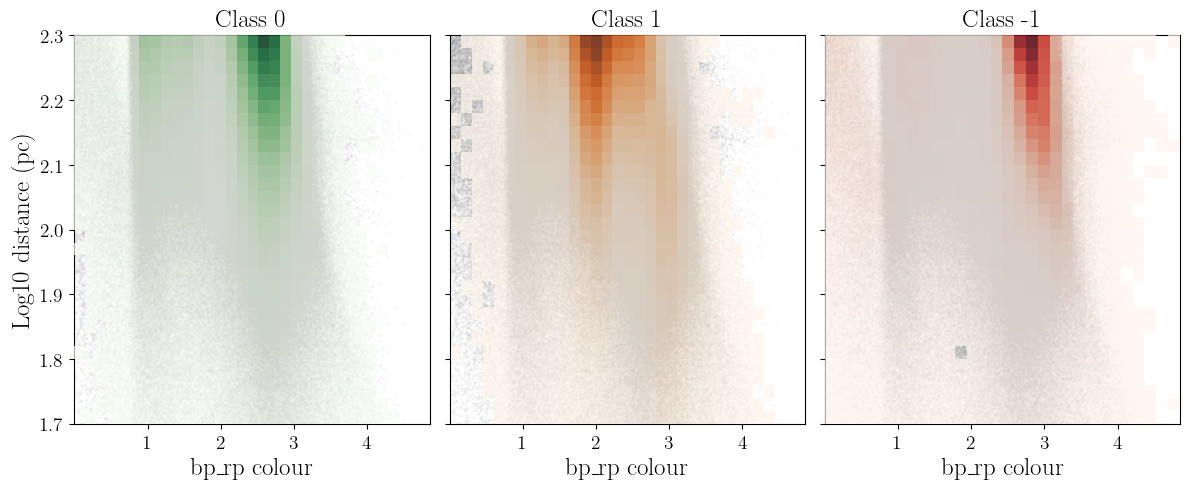

In [35]:
crap_table = working_table[working_table["predicted_class"] == 0]
bp_rp_0 = crap_table["bp_rp"]
parallax_0 = np.log10(1000/crap_table["parallax"])

crap_table = working_table[working_table["predicted_class"] == 1]
bp_rp_1 = crap_table["bp_rp"]
parallax_1 = np.log10(1000/crap_table["parallax"])

crap_table = working_table[working_table["predicted_class"] < 0]
bp_rp_n = crap_table["bp_rp"]
parallax_n = np.log10(1000/crap_table["parallax"])

ALPHA = 0.03

fig, axs = plt.subplots(1, 3, figsize=(12, 5), sharex=True, sharey=True)
ax = axs[0]
ax.set_title("Class 0")
ax.set_ylabel("Log10 distance (pc)")
ax.set_xlabel("bp_rp colour")
ax.scatter(bp_rp_1, parallax_1, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_n, parallax_n, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_0, parallax_0, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.hist2d(bp_rp_0, parallax_0, bins=30, cmap="Greens", cmin=1, zorder=10, alpha=0.7)

ax = axs[1]
ax.set_title("Class 1")
ax.set_xlabel("bp_rp colour")
ax.scatter(bp_rp_1, parallax_1, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_n, parallax_n, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_0, parallax_0, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.hist2d(bp_rp_1, parallax_1, bins=30, cmap="Oranges", cmin=1, zorder=10, alpha=0.7)

ax = axs[2]
ax.set_title("Class -1")
ax.set_xlabel("bp_rp colour")
ax.scatter(bp_rp_1, parallax_1, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_n, parallax_n, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_0, parallax_0, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.hist2d(bp_rp_n, parallax_n, bins=30, cmap="Reds", cmin=1, zorder=10, alpha=0.7)

plt.tight_layout()

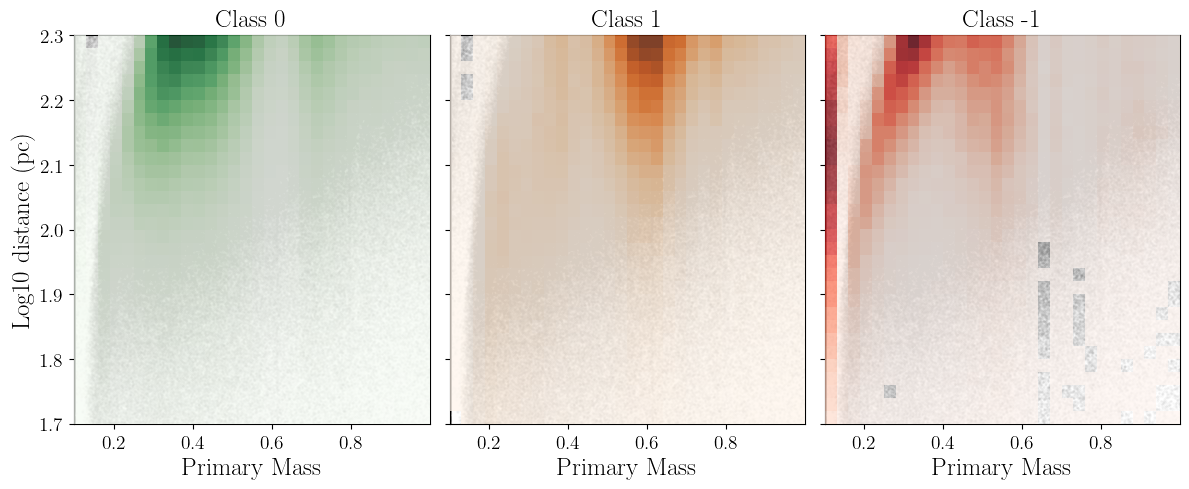

In [37]:
crap_table = working_table[working_table["predicted_class"] == 0]
bp_rp_0 = crap_table["mass_single"]
parallax_0 = np.log10(1000/crap_table["parallax"])

crap_table = working_table[working_table["predicted_class"] == 1]
bp_rp_1 = crap_table["mass_single"]
parallax_1 = np.log10(1000/crap_table["parallax"])

crap_table = working_table[working_table["predicted_class"] < 0]
bp_rp_n = crap_table["mass_single"]
parallax_n = np.log10(1000/crap_table["parallax"])

ALPHA = 0.03

fig, axs = plt.subplots(1, 3, figsize=(12, 5), sharex=True, sharey=True)
ax = axs[0]
ax.set_title("Class 0")
ax.set_ylabel("Log10 distance (pc)")
ax.set_xlabel("Primary Mass")
ax.scatter(bp_rp_1, parallax_1, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_n, parallax_n, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_0, parallax_0, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.hist2d(bp_rp_0, parallax_0, bins=30, cmap="Greens", cmin=1, zorder=10, alpha=0.7)

ax = axs[1]
ax.set_title("Class 1")
ax.set_xlabel("Primary Mass")
ax.scatter(bp_rp_1, parallax_1, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_n, parallax_n, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_0, parallax_0, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.hist2d(bp_rp_1, parallax_1, bins=30, cmap="Oranges", cmin=1, zorder=10, alpha=0.7)

ax = axs[2]
ax.set_title("Class -1")
ax.set_xlabel("Primary Mass")
ax.scatter(bp_rp_1, parallax_1, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_n, parallax_n, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_0, parallax_0, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.hist2d(bp_rp_n, parallax_n, bins=30, cmap="Reds", cmin=1, zorder=10, alpha=0.7)

plt.tight_layout()

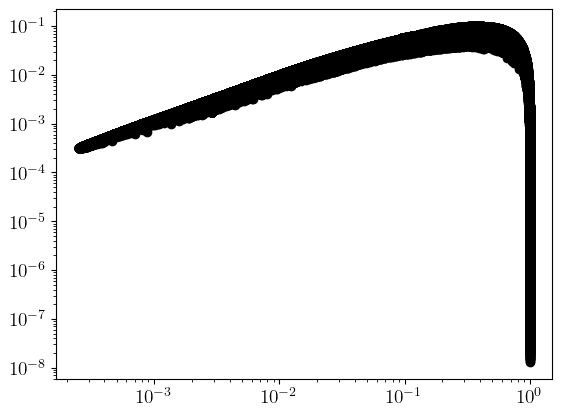

In [62]:
plt.scatter(working_table["flux_ratio_mean"],working_table["flux_ratio_std"])
plt.yscale("log")
plt.xscale("log")

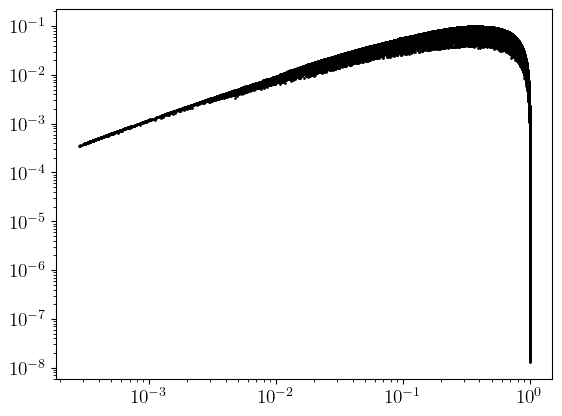

In [67]:
crap_table = working_table[working_table["predicted_class"] == 1]
plt.scatter(crap_table["flux_ratio_mean"],crap_table["flux_ratio_std"], s=1)
plt.yscale("log")
plt.xscale("log")

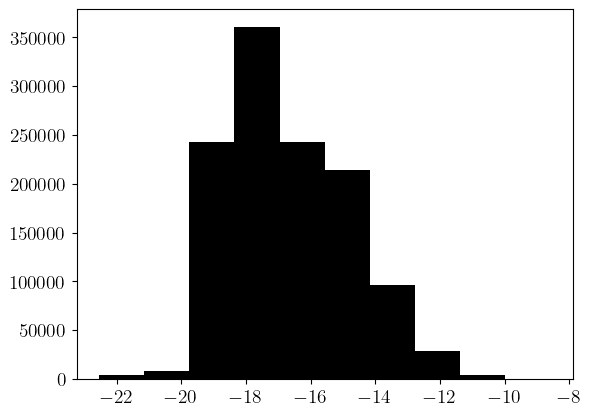

In [50]:
plt.hist(np.log10(working_table["flux_ratio_mean"])-(working_table["phot_g_mean_mag"]));

/tmp/ipykernel_1268145/3855135762.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("Greens")
/tmp/ipykernel_1268145/3855135762.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("Oranges")
/tmp/ipykernel_1268145/3855135762.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("Reds")


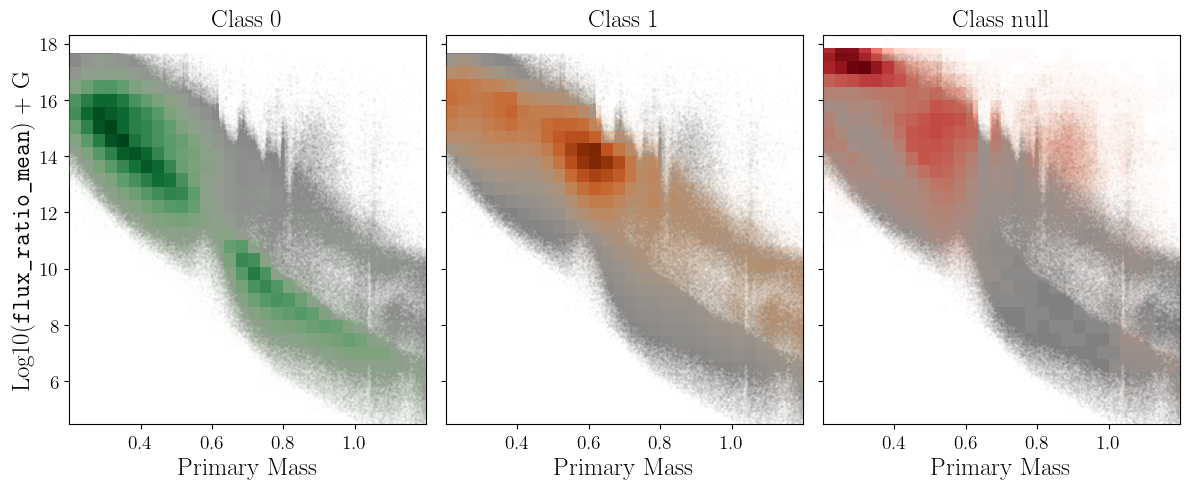

In [93]:
crap_table = working_table[working_table["predicted_class"] == 0]
bp_rp_0 = crap_table["mass_single"]
parallax_0 = np.log10(crap_table["flux_ratio_mean"])+(crap_table["phot_g_mean_mag"])

crap_table = working_table[working_table["predicted_class"] == 1]
bp_rp_1 = crap_table["mass_single"]
parallax_1 = np.log10(crap_table["flux_ratio_mean"])+(crap_table["phot_g_mean_mag"])

crap_table = working_table[working_table["predicted_class"] < 0]
bp_rp_n = crap_table["mass_single"]
parallax_n = np.log10(crap_table["flux_ratio_mean"])+(crap_table["phot_g_mean_mag"])

ALPHA = 0.03

fig, axs = plt.subplots(1, 3, figsize=(12, 5), sharex=True, sharey=True)
ax = axs[0]
ax.set_title("Class 0")
ax.set_ylabel(r"Log10($\texttt{flux\_ratio\_mean}$) + G")
ax.set_xlabel("Primary Mass")
ax.scatter(bp_rp_1, parallax_1, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_n, parallax_n, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_0, parallax_0, s=1, color="grey", alpha=ALPHA, zorder=0)
cmap = matplotlib.cm.get_cmap("Greens")
colors = cmap(np.linspace(0, 1, 256))
colors[:, -1] = np.linspace(0, 1, 256)
custom_cmap = plt.matplotlib.colors.ListedColormap(colors)
ax.hist2d(bp_rp_0, parallax_0, bins=30, cmap=custom_cmap, zorder=10, norm=matplotlib.colors.PowerNorm(0.4))

ax = axs[1]
ax.set_title("Class 1")
ax.set_xlabel("Primary Mass")
ax.scatter(bp_rp_1, parallax_1, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_n, parallax_n, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_0, parallax_0, s=1, color="grey", alpha=ALPHA, zorder=0)
cmap = matplotlib.cm.get_cmap("Oranges")
colors = cmap(np.linspace(0, 1, 256))
colors[:, -1] = np.linspace(0, 1, 256)
custom_cmap = plt.matplotlib.colors.ListedColormap(colors)
ax.hist2d(bp_rp_1, parallax_1, bins=30, cmap=custom_cmap, zorder=10, norm=matplotlib.colors.PowerNorm(0.4))

ax = axs[2]
ax.set_title("Class null")
ax.set_xlabel("Primary Mass")
ax.scatter(bp_rp_1, parallax_1, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_n, parallax_n, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_0, parallax_0, s=1, color="grey", alpha=ALPHA, zorder=0)
cmap = matplotlib.cm.get_cmap("Reds")
colors = cmap(np.linspace(0, 1, 256))
colors[:, -1] = np.linspace(0, 1, 256)
custom_cmap = plt.matplotlib.colors.ListedColormap(colors)
ax.hist2d(bp_rp_n, parallax_n, bins=30, cmap=custom_cmap, zorder=10, norm=matplotlib.colors.PowerNorm(0.3))

plt.tight_layout()

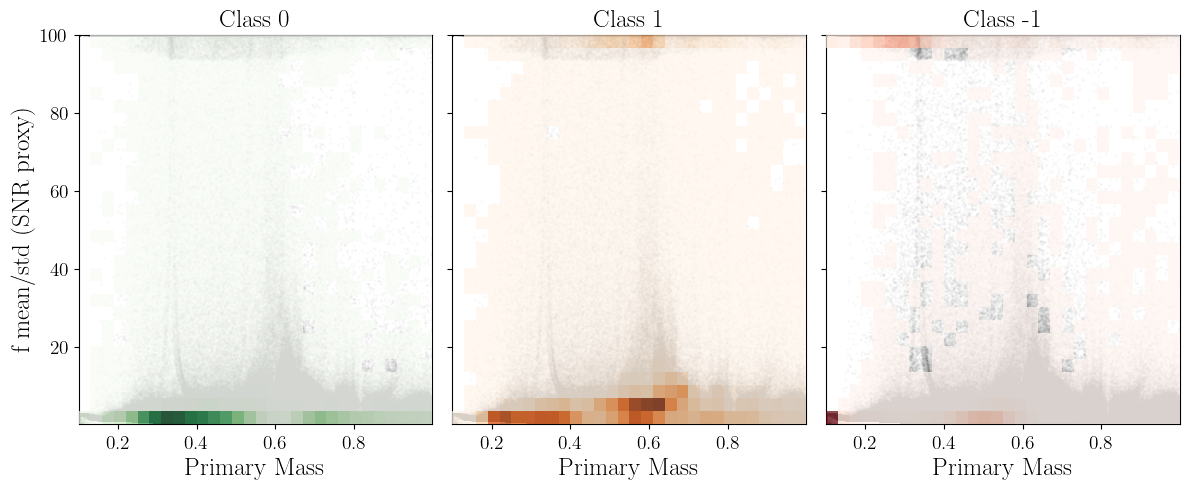

In [48]:
crap_table = working_table[working_table["predicted_class"] == 0]
bp_rp_0 = crap_table["mass_single"]
parallax_0 = crap_table["flux_ratio_mean"]/np.maximum(crap_table["flux_ratio_std"], 0.01)

crap_table = working_table[working_table["predicted_class"] == 1]
bp_rp_1 = crap_table["mass_single"]
parallax_1 = crap_table["flux_ratio_mean"]/np.maximum(crap_table["flux_ratio_std"], 0.01)

crap_table = working_table[working_table["predicted_class"] < 0]
bp_rp_n = crap_table["mass_single"]
parallax_n = crap_table["flux_ratio_mean"]/np.maximum(crap_table["flux_ratio_std"], 0.01)

ALPHA = 0.03

fig, axs = plt.subplots(1, 3, figsize=(12, 5), sharex=True, sharey=True)
ax = axs[0]
ax.set_title("Class 0")
ax.set_ylabel("f mean/std (SNR proxy)")
ax.set_xlabel("Primary Mass")
ax.scatter(bp_rp_1, parallax_1, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_n, parallax_n, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_0, parallax_0, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.hist2d(bp_rp_0, parallax_0, bins=30, cmap="Greens", cmin=1, zorder=10, alpha=0.7)

ax = axs[1]
ax.set_title("Class 1")
ax.set_xlabel("Primary Mass")
ax.scatter(bp_rp_1, parallax_1, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_n, parallax_n, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_0, parallax_0, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.hist2d(bp_rp_1, parallax_1, bins=30, cmap="Oranges", cmin=1, zorder=10, alpha=0.7)

ax = axs[2]
ax.set_title("Class -1")
ax.set_xlabel("Primary Mass")
ax.scatter(bp_rp_1, parallax_1, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_n, parallax_n, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.scatter(bp_rp_0, parallax_0, s=1, color="grey", alpha=ALPHA, zorder=0)
ax.hist2d(bp_rp_n, parallax_n, bins=30, cmap="Reds", cmin=1, zorder=10, alpha=0.7)

plt.tight_layout()

trim to objects in our mass and parallax range which had the single and binary star fits

note: only 7 objects didn't have a successful single or binary star fit

In [87]:
PARALLAX_MASK = (new_table["parallax"] < 20) & (new_table["parallax"] > 5) # 50-200pc
MASS_MASK = (new_table["mass_single"] < 1.2) & (new_table["mass_single"] > 0.2)
# ARBITRARY_CUT = new_table["bp_rp"] > 1.5
SUCCESS_CUT = (new_table["fit_success_binary"]) & (new_table["fit_success_single"])
total_mask = PARALLAX_MASK & MASS_MASK & SUCCESS_CUT #& ARBITRARY_CUT 
working_table = new_table[total_mask]

In [88]:
len(working_table[working_table["predicted_class"] == 0]), len(working_table[working_table["predicted_class"] == 1]), len(working_table[working_table["predicted_class"] < 0])

(757657, 354045, 89957)

In [89]:
len(working_table[working_table["predicted_class"] == 0])/len(working_table), len(working_table[working_table["predicted_class"] == 1])/len(working_table), len(working_table[working_table["predicted_class"] < 0])/len(working_table)

(0.6305091544273376, 0.2946301737847426, 0.07486067178791987)

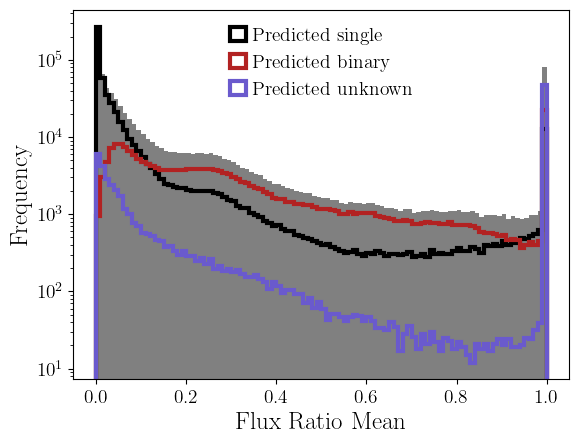

In [ ]:
tbins = plt.hist(working_table["flux_ratio_mean"], color="grey", bins=100);
plt.hist(working_table[working_table["predicted_class"] == 0]["flux_ratio_mean"], bins=tbins[1], **hist_defaults, label="Predicted single");
plt.hist(working_table[working_table["predicted_class"] == 1]["flux_ratio_mean"], bins=tbins[1], **hist_defaults, label="Predicted binary");
plt.hist(working_table[working_table["predicted_class"] < 0]["flux_ratio_mean"], bins=tbins[1], **hist_defaults, label="Predicted unknown");
plt.yscale("log");
plt.xlabel("Flux Ratio Mean");
plt.ylabel("Frequency");
plt.legend();

In [9]:
len(working_table)

1023835

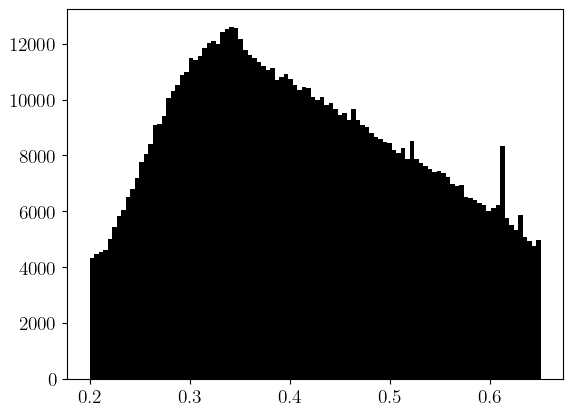

In [39]:
plt.hist(working_table["mass_single"], bins=100);

## Make cuts to effectively single stars

In [12]:
SINGLE_MASK = working_table["predicted_class"] == 0
LUM_CUT = working_table["flux_ratio_mean"] < 10**(-1.5)

In [13]:
reduced_table = working_table[SINGLE_MASK & LUM_CUT]
len(working_table[SINGLE_MASK]), len(working_table[LUM_CUT]), len(working_table[SINGLE_MASK & LUM_CUT])

(648996, 483961, 452587)

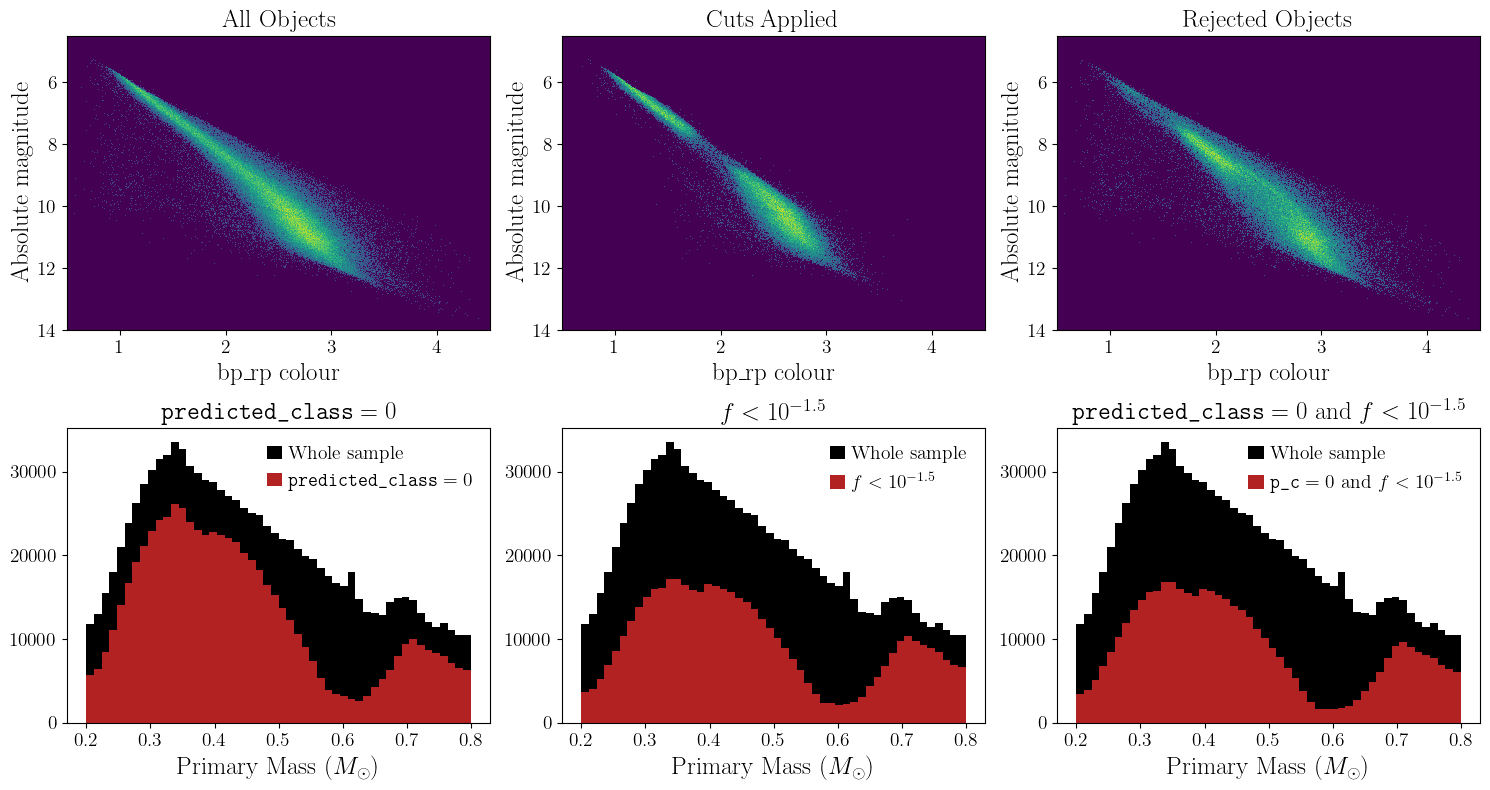

In [18]:
fig, axs = plt.subplots(2, 3, figsize=(15,8))
ranges = [(0.5, 4.5), (4.5, 14)]

### CMD WITH EVERYTHING
new_table = working_table
bp_rp = new_table["bp_rp"]
parallax = new_table["parallax"]
gmag = new_table["phot_g_mean_mag"]
absolute_magnitudes = gmag + 5 * np.log10(parallax) - 10

ax = axs[0,0]
ax.hist2d(bp_rp, absolute_magnitudes, bins=1000, norm=matplotlib.colors.PowerNorm(0.4), range=ranges);
ax.invert_yaxis();
ax.set_ylabel("Absolute magnitude");
ax.set_xlabel("bp_rp colour");
ax.set_title("All Objects");


### CMD WITH THE REDUCED SAMPLE
new_table = reduced_table
bp_rp = new_table["bp_rp"]
parallax = new_table["parallax"]
gmag = new_table["phot_g_mean_mag"]
absolute_magnitudes = gmag + 5 * np.log10(parallax) - 10

ax = axs[0,1]
ax.hist2d(bp_rp, absolute_magnitudes, bins=1000, norm=matplotlib.colors.PowerNorm(0.4), range=ranges);
ax.invert_yaxis();
ax.set_ylabel("Absolute magnitude");
ax.set_xlabel("bp_rp colour");
ax.set_title("Cuts Applied");

### CMD WITH THE REJECTED OBJECTS
new_table = working_table[~(SINGLE_MASK & LUM_CUT)]
bp_rp = new_table["bp_rp"]
parallax = new_table["parallax"]
gmag = new_table["phot_g_mean_mag"]
absolute_magnitudes = gmag + 5 * np.log10(parallax) - 10

ax = axs[0,2]
ax.hist2d(bp_rp, absolute_magnitudes, bins=1000, norm=matplotlib.colors.PowerNorm(0.4), range=ranges);
ax.set_ylabel("Absolute magnitude");
ax.set_xlabel("bp_rp colour");
ax.invert_yaxis();
ax.set_title("Rejected Objects");

### MASS HISTOGRAM OF THE CUTS
ax = axs[1,0]
tbins = ax.hist(working_table["mass_single"], bins=50, label="Whole sample");
ax.hist(working_table[SINGLE_MASK]["mass_single"], bins=tbins[1], label=r"$\texttt{predicted\_class}=0$");
ax.legend();
ax.set_xlabel(r"Primary Mass ($M_\odot$)");
ax.set_title(r"$\texttt{predicted\_class}=0$");

### MASS HISTOGRAM OF THE CUTS
ax = axs[1,1]
tbins = ax.hist(working_table["mass_single"], bins=50, label="Whole sample");
ax.hist(working_table[LUM_CUT]["mass_single"], bins=tbins[1], label=r"$f<10^{-1.5}$");
ax.legend();
ax.set_xlabel(r"Primary Mass ($M_\odot$)");
ax.set_title(r"$f<10^{-1.5}$");

### MASS HISTOGRAM OF THE CUTS
ax = axs[1,2]
tbins = ax.hist(working_table["mass_single"], bins=50, label="Whole sample");
ax.hist(working_table[SINGLE_MASK & LUM_CUT]["mass_single"], bins=tbins[1], label=r"$\texttt{p\_c}=0$ and $f<10^{-1.5}$");
ax.legend();
ax.set_xlabel(r"Primary Mass ($M_\odot$)");
ax.set_title(r"$\texttt{predicted\_class}=0$ and $f<10^{-1.5}$");

plt.tight_layout()

In [25]:
reduced_table.write('./data/2026-04-24_M_to_G_stars_cut.fits', format='fits', overwrite=True)

## Pull solution type, binary properties from gaia

In [5]:
reduced_table = Table.read('./data/2026-04-24_M_to_G_stars_cut.fits', format='fits')

In [ ]:
job = Gaia.launch_job_async("""SELECT *
                                FROM gaiadr3.nss_two_body_orbit AS g
                                WHERE g.parallax > 5
                                AND g.parallax < 20
                                """)

nss_table = job.get_results()

job = Gaia.launch_job_async("""SELECT *
                                FROM gaiadr3.nss_acceleration_astro AS g
                                WHERE g.parallax > 5
                                AND g.parallax < 20
                                """)

accel_table = job.get_results()

In [ ]:
nss_table = Table.read('../BigData/NSSTableKpc.fits', format='fits')
accel_table = Table.read('./data/AccelTableKpc.fits', format='fits')

In [ ]:
# a test
job = Gaia.launch_job_async(r"""select pmra, pmdec, ruwe
                        from gaiadr3.gaia_source 
                        where source_id = 5478926884285078784""")
results = job.get_results()

In [27]:
import os
os.environ["XDG_CACHE_HOME"] = os.path.expanduser("~/.astroquery_tmp")

In [28]:
import time

In [ ]:
def chunk_list(lst, n):
    """Yield successive n-sized chunks from lst."""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

batch_size = 1000

all_results = []
counter = 0

for batch in tqdm(list(chunk_list(reduced_table["source_id"], batch_size))):
    ids_str = ",".join(str(sid) for sid in batch)
    query = f"""
    SELECT source_id, pmra, pmdec, ruwe
    FROM gaiadr3.gaia_source
    WHERE source_id IN ({ids_str})
    """
    complete = False
    while not complete:
        try:
            job = Gaia.launch_job_async(query, verbose=False)
            results = job.get_results()
            complete = True
        except:
            print(f"{counter} Failed")
        time.sleep(1)

    all_results.append(results.to_pandas())
    counter += 1

df = pd.concat(all_results, ignore_index=True)

  0%|          | 0/523 [00:00<?, ?it/s]

INFO: Query finished. [astroquery.utils.tap.core]
1 Failed


In [60]:
working_table.add_column(np.zeros(len(working_table)), name="pmra")
working_table.add_column(np.zeros(len(working_table)), name="pmdec")
working_table.add_column(np.zeros(len(working_table)), name="ruwe")
working_table.add_column(np.zeros(len(working_table)), name="solution_type")
working_table.add_column(np.zeros(len(working_table)), name="period")
working_table.add_column(np.zeros(len(working_table)), name="eccentricity")

In [61]:
mask = np.isin(working_table["source_id"], df["source_id"])  # boolean mask for rows to update
data_indices = np.where(mask)[0]

# Step 2: Map update indices
update_map = {sid: i for i, sid in enumerate(df['source_id'])}

# Step 3: Update only the desired columns
for col in ['pmra', 'pmdec', 'ruwe']: #, 'period', 'eccentricity']:
    # Pick corresponding values from updates_df
    working_table[col][data_indices] = [df[col][update_map[sid]] for sid in working_table['source_id'][data_indices]]

In [44]:
accel_ids = list(accel_table["source_id"])
nss_ids = list(nss_table["source_id"])

for row in tqdm(working_table):
    if row["ruwe"] < 1.4:
        row["solution_type"] = int(0)
    elif row["source_id"] in nss_ids:
        row["solution_type"] = int(12)
    elif row["source_id"] in accel_ids:
        if accel_table[accel_table["source_id"] == row["source_id"]]["nss_solution_type"][0] == "Acceleration7":
            row["solution_type"] = int(7)
        elif accel_table[accel_table["source_id"] == row["source_id"]]["nss_solution_type"][0] == "Acceleration9":
            row["solution_type"] = int(9)
    else:
        row["solution_type"] = int(5)

  0%|          | 0/72624 [00:00<?, ?it/s]

In [46]:
old_table = Table.read('./data/all_mdwarfs_65.fits', format='fits')

In [51]:
from astropy.table import vstack

In [52]:
new_table = vstack([old_table, working_table])

In [56]:
new_table.write('./data/all_mdwarfs_65_ext.fits', format='fits', overwrite=True)

### Adjusting Parallaxes using CBJ distances

In [50]:
adjustment_table = working_table[SINGLE_MASK & LUM_CUT]

In [63]:
service = pyvo.dal.TAPService("https://gea.esac.esa.int/tap-server/tap")

In [66]:
def chunk_list(lst, n):
    """Yield successive n-sized chunks from lst."""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

batch_size = 10000

all_results = []

for batch in tqdm(list(chunk_list(adjustment_table["source_id"], batch_size))):
    ids_table = Table()
    ids_table["source_id"] = batch

    query = """
        SELECT d.source_id, d.r_med_geo, d.r_med_photogeo
        FROM external.gaiaedr3_distance AS d
        JOIN TAP_UPLOAD.ids AS u
        ON d.source_id = u.source_id
    """
    complete = False
    while not complete:
        try:
            job = service.run_async(query, uploads={"ids": ids_table})
            result = job.to_table()
            
            if len(result) > 0:
                all_results.append(result)
                complete = True
        except:
            print("FUck!")
            time.sleep(1)
    

# Combine everything into ONE table
final_table = vstack(all_results)

  0%|          | 0/30 [00:00<?, ?it/s]

FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!
FUck!


In [67]:
merged_table = join(adjustment_table, final_table, keys="source_id", join_type="inner")

How many objects would have bad parallaxes, or parallaxes that place them out of our range?

In [68]:
OUTLIER_MASK = (merged_table["r_med_photogeo"] < 225) #(abs(merged_table["r_med_photogeo"] - 1000/merged_table["parallax"]) / (1000/merged_table["parallax"]) < 0.1) & (merged_table["r_med_photogeo"] < 200)

len(merged_table[np.invert(OUTLIER_MASK)])

25

In [69]:
len(np.where(merged_table[np.invert(OUTLIER_MASK)]["solution_type"] == 5)[0])

25

They're all high RUWE objects

Apply the single, flux, and outlier cuts

In [70]:
# SINGLE_MASK = merged_table["predicted_class"] == 0
# LUM_CUT = merged_table["flux_ratio_mean"] < 10**(-1.5)
OUTLIER_MASK = (merged_table["r_med_photogeo"] < 225) # (abs(merged_table["r_med_photogeo"] - 1000/merged_table["parallax"]) / (1000/merged_table["parallax"]) < 0.1) & (merged_table["r_med_photogeo"] < 200)
final_catalogue = merged_table[OUTLIER_MASK] # for now don't bother #& OUTLIER_MASK]
final_catalogue.write('./data/single_mdwarfs_65_ext.fits', format='fits', overwrite=True)

## Isochrone cut

In [43]:
final_0306 = Table.read('./data/single_mdwarfs_65_ext.fits', format='fits')
final_0204 = Table.read('./data/single_mdwarfs_200pc.fits', format='fits')
new_0203 = final_0204[(final_0204["mass_single"] < 0.3) & (final_0204["flux_ratio_mean"] < 10**(-1.5))]
combined_catalogue = vstack([final_0306, new_0203])
#combined_catalogue.write("./data/combined_catalogue_23_04_26.fits", format='fits', overwrite=True)

In [44]:
new_table = Table()
new_table.add_column(np.array(msms["table"]["columns"]["bp_rp"]["data"]), name="bp_rp")
new_table.add_column(np.array(msms["table"]["columns"]["parallax"]["data"]), name="parallax")
new_table.add_column(np.array(msms["table"]["columns"]["phot_g_mean_mag"]["data"]), name="phot_g_mean_mag")
bp_rp_all = new_table["bp_rp"]
parallax = new_table["parallax"]
gmag = new_table["phot_g_mean_mag"]
absolute_magnitudes_all = gmag + 5 * np.log10(parallax) - 10

In [45]:
final_table = combined_catalogue

In [46]:
print_table(final_table)
len(final_table)

,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),94.79,4.59,0.26,0.16,0.20
Counts,341127,16501,945,571,714


359858

In [47]:
isochrone_data = np.genfromtxt('../DR3_planet_candidate_identification/data/isochrones.dat',
                     skip_header=13,
                     skip_footer=1,
                     names=True,
                     dtype=None)
print(np.unique(isochrone_data["logAge"]))
print(np.unique(isochrone_data["MH"]))

def outside_isochrones(iso_x, iso_y, target_point):
    return np.interp(x=target_point[0], xp=iso_x, fp=iso_y) > target_point[1]

[7.      7.1     7.2     7.3     7.4     7.5     7.6     7.7     7.8
 7.9     8.      8.1     8.2     8.3     8.4     8.5     8.6     8.7
 8.8     8.9     9.      9.1     9.2     9.3     9.4     9.5     9.60001
 9.70001 9.80001 9.90001]
[-0.6 -0.5 -0.4 -0.3 -0.2 -0.1 -0.   0.1  0.2  0.3]


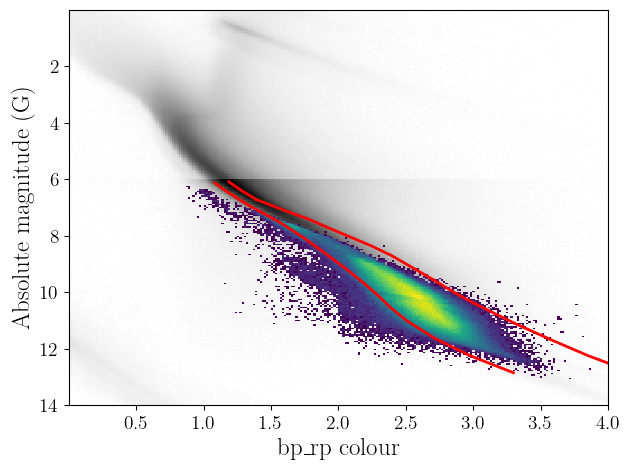

In [48]:
bp_rps = final_table["bp_rp"]
parallax = final_table["parallax"]
gmag = final_table["phot_g_mean_mag"]
absolute_mags = gmag + 5 * np.log10(parallax) - 10

fig, ax = plt.subplots(1, 1)

# --- Background (full dataset) ---
H_bg, xedges, yedges, _ = plt.hist2d(
    bp_rp_all,
    absolute_magnitudes_all,
    bins=300,
    cmap="binary",
    norm=matplotlib.colors.PowerNorm(0.4),
    zorder=1
)

# --- Foreground histogram (compute only) ---
H_fg, _, _ = np.histogram2d(
    bp_rps,
    absolute_mags,
    bins=[xedges, yedges]  # IMPORTANT: same binning
)

# Mask zero bins
H_fg_masked = np.ma.masked_where(H_fg == 0, H_fg)

# Colormap with transparent "bad" values
cmap = plt.cm.viridis.copy()
cmap.set_bad(alpha=0)  # <-- makes masked bins invisible

# Plot foreground
plt.pcolormesh(
    xedges,
    yedges,
    H_fg_masked.T,
    cmap=cmap,
    norm=matplotlib.colors.PowerNorm(0.4),
    zorder=2
)

# fig, ax = plt.subplots(1, 1)

#plt.hist2d(bp_rps, absolute_mags, bins=1000, norm=matplotlib.colors.PowerNorm(0.4));

isochrone_mags = isochrone_data["Gmag"]
isochrone_cols = isochrone_data["G_BPmag"] - isochrone_data["G_RPmag"]
edge_mask = (isochrone_cols < 4.5) & (isochrone_mags > 6) & (isochrone_mags < 13) & (isochrone_data["MH"] == -0.3) & (isochrone_data["logAge"] == 9.90001)
edge_isochrone_cols, edge_isochrone_mags = isochrone_cols[edge_mask], isochrone_mags[edge_mask]
plt.plot(edge_isochrone_cols, edge_isochrone_mags, c="r", linewidth=2, label="M/H=-0.3, logAge=9.9");

isochrone_mags = isochrone_data["Gmag"]
isochrone_cols = isochrone_data["G_BPmag"] - isochrone_data["G_RPmag"]
upper_mask = (isochrone_mags < 13) & (isochrone_mags > 6) & (isochrone_cols < 5) & (isochrone_data["MH"] == 0.3) & (isochrone_data["logAge"] == 7.8)
edge_isochrone_cols, edge_isochrone_mags = isochrone_cols[upper_mask], isochrone_mags[upper_mask]
plt.plot(edge_isochrone_cols, edge_isochrone_mags, c="r", linewidth=2);

ax.invert_yaxis()
ax.set_ylim(bottom=14) #[14, 6])
ax.set_xlim(right=4)#[0.5,4])
ax.set_ylabel("Absolute magnitude (G)");
ax.set_xlabel("bp_rp colour");

plt.tight_layout();
#plt.savefig("./plots/isochrone_cuts.jpg", dpi=800);

In [51]:
def get_sorted_isochrone_points(isochrone_mags, isochrone_cols, edge_mask, get_edgevals=False):
    edge_isochrone_cols, edge_isochrone_mags = isochrone_cols[edge_mask], isochrone_mags[edge_mask]
    if get_edgevals:
        return edge_isochrone_cols, edge_isochrone_mags
    coords = list(zip(edge_isochrone_mags, edge_isochrone_cols))
    coords.sort()
    x_sorted, y_sorted = zip(*coords)
    return x_sorted, y_sorted

isochrone_mask = (isochrone_cols < 4.5) & (isochrone_mags > 3.5) & (isochrone_mags < 13) & (isochrone_data["MH"] == -0.3) & (isochrone_data["logAge"] == 9.90001)
x_sorted, y_sorted = get_sorted_isochrone_points(isochrone_mags, isochrone_cols, isochrone_mask)

upper_isochrone_mask = (isochrone_mags < 13) & (isochrone_mags > 3.5) & (isochrone_cols < 5) & (isochrone_data["MH"] == 0.3) & (isochrone_data["logAge"] == 7.8)
u_x_sorted, u_y_sorted = get_sorted_isochrone_points(isochrone_mags, isochrone_cols, upper_isochrone_mask)

table_isochrone_mask = np.invert(outside_isochrones(x_sorted, y_sorted, (absolute_mags, bp_rps))) & outside_isochrones(u_x_sorted, u_y_sorted, (absolute_mags, bp_rps))
reduced_t_loaded = final_table[table_isochrone_mask]
rejected = final_table[np.invert(table_isochrone_mask)]

In [52]:
print_table(reduced_t_loaded, "after isochrone cut")

,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),95.44,3.95,0.27,0.16,0.19
Counts,327969,13570,916,545,646


In [53]:
print_table(rejected, "removed objects")

,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),81.16,18.08,0.18,0.16,0.42
Counts,13158,2931,29,26,68


In [54]:
len(rejected)/len(reduced_t_loaded)*100

4.717645484015528

In [55]:
len(reduced_t_loaded)

343646

In [56]:
reduced_t_loaded.write('./data/combined_catalogue_23_04_26.fits', format='fits', overwrite=True)

## Parameter Distributions

In [57]:
final_catalogue = Table.read('./data/combined_catalogue_23_04_26.fits', format='fits')

In [58]:
print_table(final_catalogue)

,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),95.44,3.95,0.27,0.16,0.19
Counts,327969,13570,916,545,646


In [59]:
final_catalogue.add_column(np.zeros(len(final_catalogue)), name="mass_index")

masses = np.array([t["mass_single"] for t in final_catalogue])
percs = np.percentile(masses, np.arange(10, 110, 10))
for row in tqdm(final_catalogue):
    row["mass_index"] = np.minimum(np.digitize(row["mass_single"], percs), 9)

  0%|          | 0/343646 [00:00<?, ?it/s]

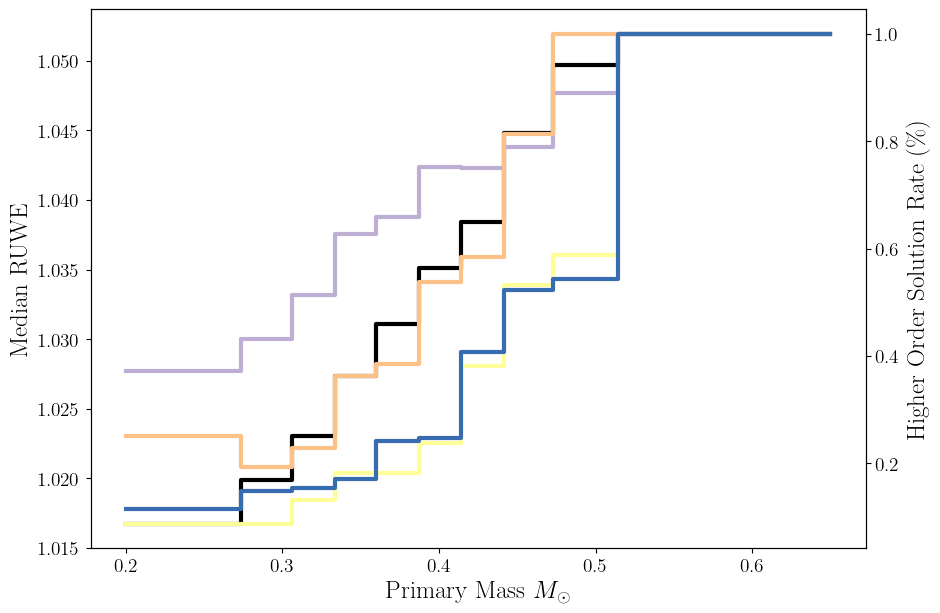

In [60]:
fig, ax = plt.subplots(1,1, figsize=(10,7))

# compute bins for drawing
mass_lims_b = np.percentile(masses, np.arange(0, 110, 10))
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

# draw median RUWE
pts = [np.median(np.array([o["ruwe"] for o in final_catalogue[final_catalogue["mass_index"] == i]])) for i in range(10)]
ax.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(pts,2), lw=3);
ax.set_xlabel(r"Primary Mass $M_\odot$");
ax.set_ylabel("Median RUWE");

# create second axis
ax2 = ax.twinx()
soltype_cols = plt.get_cmap('Accent')(np.linspace(0, 1, 8))[:5]

# draw high RUWE rate
for ind, k in enumerate([5,7,9,12]):
    counts = np.array([len(final_catalogue[(final_catalogue["mass_index"] == i) & (final_catalogue["solution_type"] == k)]) for i in range(10)])
    lens = np.array([len(final_catalogue[final_catalogue["mass_index"] == i]) for i in range(10)])
    rates = counts / lens * 100
    #errs = np.sqrt(counts) / lens * 100

    ax2.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(rates,2)/np.max(rates), lw=3, c=soltype_cols[ind+1]);
# counts = np.array([len(final_catalogue[(final_catalogue["mass_index"] == i) & (final_catalogue["solution_type"] > 5)]) for i in range(10)])
# lens = np.array([len(final_catalogue[final_catalogue["mass_index"] == i]) for i in range(10)])
# rates = counts / lens * 100
#errs = np.sqrt(counts) / lens * 100

#ax2.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(rates,2), lw=3, linestyle="--", color="slateblue");
    
ax2.set_ylabel(r"Higher Order Solution Rate (\%)");

## "corner" plot

In [61]:
final_table = Table.read('./data/combined_catalogue_23_04_26.fits', format='fits')
final_table["distance"] = 1000/final_table["parallax"]
final_table["logruwe"] = np.log10(final_table["ruwe"])

masses = np.array([t["mass_single"] for t in final_table])

In [62]:
final_table.add_column(np.zeros(len(final_table)), name="mass_index")

masses = np.array([t["mass_single"] for t in final_table])
percs = np.percentile(masses, np.arange(10, 110, 10))
for row in tqdm(final_table):
    row["mass_index"] = np.minimum(np.digitize(row["mass_single"], percs), 9)

  0%|          | 0/343646 [00:00<?, ?it/s]

In [63]:
print_table(final_table)
len(final_table)

,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),95.44,3.95,0.27,0.16,0.19
Counts,327969,13570,916,545,646


343646

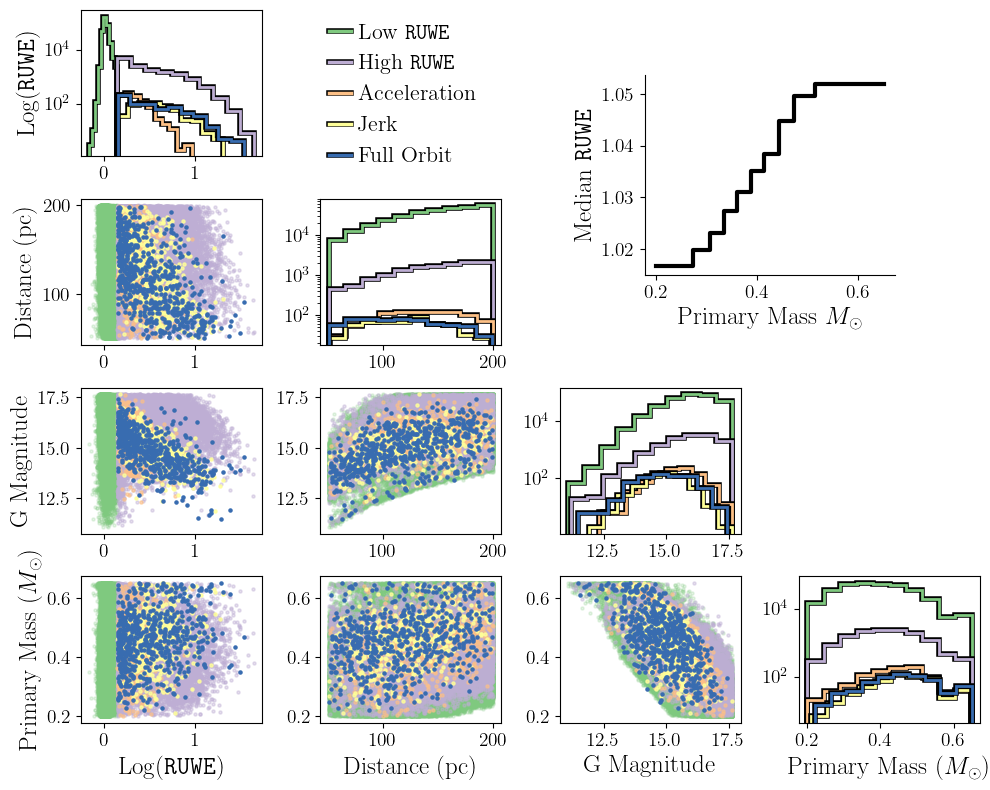

In [65]:
params = ["logruwe", "distance", "phot_g_mean_mag", "mass_single"]
labels = [r"\text{Log}(\texttt{RUWE})", "Distance (pc)", "G Magnitude", r"Primary Mass ($M_\odot$)"]
type_labels = [r"Low \texttt{RUWE}", r"High \texttt{RUWE}", "Acceleration", "Jerk", "Full Orbit"]
soltypes = [0,5,7,9,12]
colors = plt.get_cmap('Accent')(np.linspace(0, 1, 8))[:5]

n = len(params)
fig, axes = plt.subplots(n, n, figsize=(10, 8))

nbins=15

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i < j:
            ax.axis('off')
            continue

        for t in range(5):
            subset = final_table[final_table["solution_type"] == soltypes[t]]
            x = subset[params[j]]
            y = subset[params[i]]

            if i == j:
                #ax.hist(x, color="k", histtype="step", lw=4)
                ax.hist(x, color=colors[t], #range=(np.min(final_table[params[i]]), np.max(final_table[params[j]])), bins=nbins,
                        histtype="step", lw=2, 
                        path_effects=[
                        pe.Stroke(linewidth=4, foreground='black'),  # outline
                        pe.Normal()])
                ax.set_yscale("log")
            else:
                ax.scatter(x, y, s=5, color=colors[t], alpha=0.2*(t+1))

        if i == n-1:
            ax.set_xlabel(labels[j])
        if j == 0:
            ax.set_ylabel(labels[i])

# Create legend handles
handles = [
    matplotlib.lines.Line2D([0, 1], [0, 0],      # defines a line segment
           color=colors[t],     # your color per type
           lw=2.5,              # line width
           linestyle='-',       # solid line (can change)
           label=type_labels[t],
           path_effects=[
               pe.Stroke(linewidth=4, foreground='black'),  # outline
               pe.Normal()                                  # actual line on top
           ])
    for t in range(5)
]

# Add legend to figure (not individual axes)
fig.legend(
    handles=handles,
    loc='upper right',
    bbox_to_anchor=(0.50, 0.99),
    frameon=False,       # removes boundary box
    fontsize=16,         # bigger text
    handlelength=1,      # longer lines
)

plt.tight_layout()

inset_ax = fig.add_axes([0.65, 0.65, 0.25, 0.25]) 

# mass_lims_b = np.percentile(masses, np.arange(0, 110, 20))
# bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

# draw high RUWE rate
# for ind, k in enumerate([5,7,9,12]):
#     counts = np.array([len(final_catalogue[(np.isin(final_catalogue["mass_index"],[i*2, i*2+1])) & (final_catalogue["solution_type"] == k)]) for i in range(5)])
#     lens = np.array([len(final_catalogue[(np.isin(final_catalogue["mass_index"],[i*2, i*2+1]))]) for i in range(5)])
#     rates = counts / lens * 100
#     inset_ax.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(rates,2)/np.max(rates), lw=4, c="k")
#     inset_ax.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(rates,2)/np.max(rates), lw=2, c=colors[ind+1]);

# inset_ax.set_xlabel(r"Primary Mass $M_\odot$");
# inset_ax.set_ylabel(r"Relative Solution Rate");
# inset_ax.spines['top'].set_visible(False)
# inset_ax.spines['right'].set_visible(False)

# ax2 = inset_ax.twinx()
# compute bins for drawing
mass_lims_b = np.percentile(masses, np.arange(0, 110, 10))
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

# draw median RUWE
pts = np.array([np.median(np.array([o["ruwe"] for o in final_table[final_table["mass_index"] == i]])) for i in range(10)])
inset_ax.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(pts,2), lw=3);
inset_ax.set_xlabel(r"Primary Mass $M_\odot$");
inset_ax.set_ylabel(r"Median \texttt{RUWE}");
inset_ax.spines['top'].set_visible(False)
inset_ax.spines['right'].set_visible(False)

plt.savefig("./plots/SampleCornerCombined.jpg", dpi=800);

## Diagnosing a cut-off line - ignore

In [123]:
final_table = Table.read('./data/single_mdwarfs_200pc.fits', format='fits')
print_table(final_table)
final_table.add_column(np.zeros(len(final_table)), name="mass_index")

masses = np.array([t["mass_single"] for t in final_table])
percs = np.percentile(masses, np.arange(10, 110, 10))
for row in tqdm(final_table):
    row["mass_index"] = np.minimum(np.digitize(row["mass_single"], percs), 9)

final_table["distance"] = 1000/final_table["parallax"]
final_table["logruwe"] = np.log10(final_table["ruwe"])

,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),95.59,4.09,0.16,0.06,0.09
Counts,259368,11102,447,171,245


  0%|          | 0/271333 [00:00<?, ?it/s]

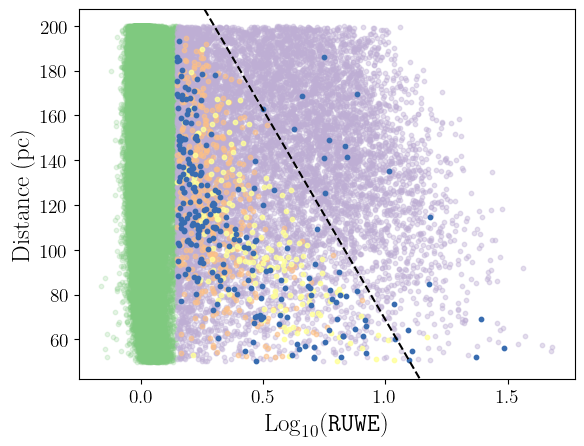

In [124]:
plt.xlabel(r"$\text{Log}_{10}$(\texttt{RUWE})");
plt.ylabel("Distance (pc)");
for t in range(5):
    subset = final_table[final_table["solution_type"] == soltypes[t]]
    x = subset["logruwe"]
    y = subset["distance"]

    plt.scatter(x, y, s=10, color=colors[t], alpha=0.2*(t+1))

plt.axline((0.3,200), (1.1,50), linestyle="--");

In [125]:
line_mask = final_table["distance"] < -187.5*final_table["logruwe"]+256.25
under_table = final_table[line_mask]

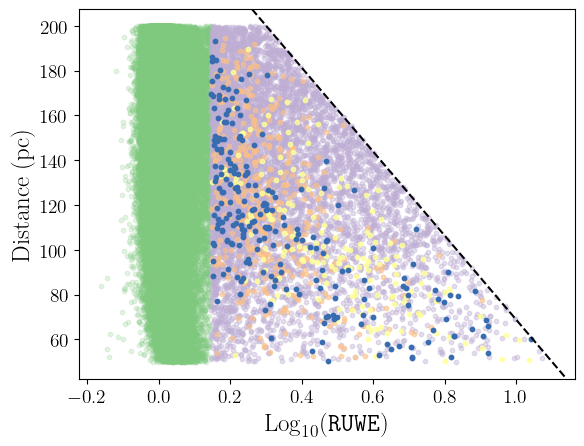

In [126]:
plt.xlabel(r"$\text{Log}_{10}$(\texttt{RUWE})");
plt.ylabel("Distance (pc)");
for t in range(5):
    subset = under_table[under_table["solution_type"] == soltypes[t]]
    x = subset["logruwe"]
    y = subset["distance"]

    plt.scatter(x, y, s=10, color=colors[t], alpha=0.2*(t+1))

plt.axline((0.3,200), (1.1,50), linestyle="--");

In [127]:
print_table(final_table, "original")
print_table(final_table[line_mask], "under line")
print_table(final_table[np.invert(line_mask)], "over line")

,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),95.59,4.09,0.16,0.06,0.09
Counts,259368,11102,447,171,245


,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),97.11,2.57,0.17,0.06,0.08
Counts,259368,6874,447,170,225


,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),0.00,99.51,0.00,0.02,0.47
Counts,0,4228,0,1,20


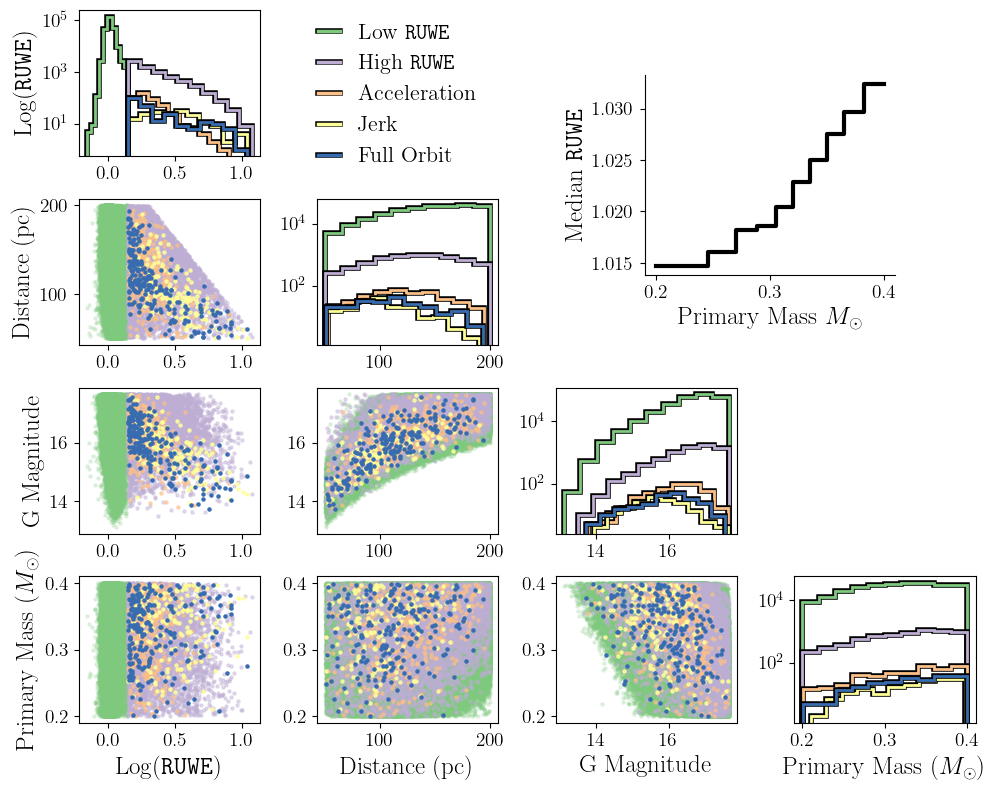

In [128]:
params = ["logruwe", "distance", "phot_g_mean_mag", "mass_single"]
labels = [r"\text{Log}(\texttt{RUWE})", "Distance (pc)", "G Magnitude", r"Primary Mass ($M_\odot$)"]
type_labels = [r"Low \texttt{RUWE}", r"High \texttt{RUWE}", "Acceleration", "Jerk", "Full Orbit"]
soltypes = [0,5,7,9,12]
colors = plt.get_cmap('Accent')(np.linspace(0, 1, 8))[:5]

n = len(params)
fig, axes = plt.subplots(n, n, figsize=(10, 8))

nbins=15

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i < j:
            ax.axis('off')
            continue

        for t in range(5):
            subset = under_table[under_table["solution_type"] == soltypes[t]]
            x = subset[params[j]]
            y = subset[params[i]]

            if i == j:
                #ax.hist(x, color="k", histtype="step", lw=4)
                ax.hist(x, color=colors[t], #range=(np.min(final_table[params[i]]), np.max(final_table[params[j]])), bins=nbins,
                        histtype="step", lw=2, 
                        path_effects=[
                        pe.Stroke(linewidth=4, foreground='black'),  # outline
                        pe.Normal()])
                ax.set_yscale("log")
            else:
                ax.scatter(x, y, s=5, color=colors[t], alpha=0.2*(t+1))

        if i == n-1:
            ax.set_xlabel(labels[j])
        if j == 0:
            ax.set_ylabel(labels[i])

# Create legend handles
handles = [
    matplotlib.lines.Line2D([0, 1], [0, 0],      # defines a line segment
           color=colors[t],     # your color per type
           lw=2.5,              # line width
           linestyle='-',       # solid line (can change)
           label=type_labels[t],
           path_effects=[
               pe.Stroke(linewidth=4, foreground='black'),  # outline
               pe.Normal()                                  # actual line on top
           ])
    for t in range(5)
]

# Add legend to figure (not individual axes)
fig.legend(
    handles=handles,
    loc='upper right',
    bbox_to_anchor=(0.50, 0.99),
    frameon=False,       # removes boundary box
    fontsize=16,         # bigger text
    handlelength=1,      # longer lines
)

plt.tight_layout()

inset_ax = fig.add_axes([0.65, 0.65, 0.25, 0.25]) 

# mass_lims_b = np.percentile(masses, np.arange(0, 110, 20))
# bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

# draw high RUWE rate
# for ind, k in enumerate([5,7,9,12]):
#     counts = np.array([len(final_catalogue[(np.isin(final_catalogue["mass_index"],[i*2, i*2+1])) & (final_catalogue["solution_type"] == k)]) for i in range(5)])
#     lens = np.array([len(final_catalogue[(np.isin(final_catalogue["mass_index"],[i*2, i*2+1]))]) for i in range(5)])
#     rates = counts / lens * 100
#     inset_ax.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(rates,2)/np.max(rates), lw=4, c="k")
#     inset_ax.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(rates,2)/np.max(rates), lw=2, c=colors[ind+1]);

# inset_ax.set_xlabel(r"Primary Mass $M_\odot$");
# inset_ax.set_ylabel(r"Relative Solution Rate");
# inset_ax.spines['top'].set_visible(False)
# inset_ax.spines['right'].set_visible(False)

# ax2 = inset_ax.twinx()
# compute bins for drawing
mass_lims_b = np.percentile(masses, np.arange(0, 110, 10))
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

# draw median RUWE
pts = np.array([np.median(np.array([o["ruwe"] for o in under_table[under_table["mass_index"] == i]])) for i in range(10)])
inset_ax.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(pts,2), lw=3);
inset_ax.set_xlabel(r"Primary Mass $M_\odot$");
inset_ax.set_ylabel(r"Median \texttt{RUWE}");
inset_ax.spines['top'].set_visible(False)
inset_ax.spines['right'].set_visible(False)

#plt.savefig("./plots/SampleCorner.jpg", dpi=800);

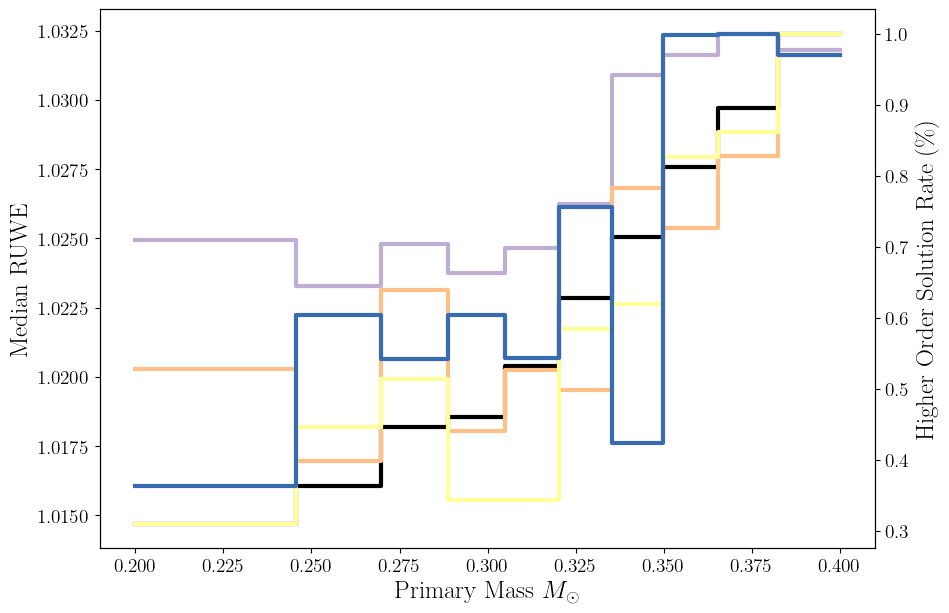

In [130]:
fig, ax = plt.subplots(1,1, figsize=(10,7))

# compute bins for drawing
mass_lims_b = np.percentile(masses, np.arange(0, 110, 10))
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

# draw median RUWE
pts = [np.median(np.array([o["ruwe"] for o in under_table[under_table["mass_index"] == i]])) for i in range(10)]
ax.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(pts,2), lw=3);
ax.set_xlabel(r"Primary Mass $M_\odot$");
ax.set_ylabel("Median RUWE");

# create second axis
ax2 = ax.twinx()
soltype_cols = plt.get_cmap('Accent')(np.linspace(0, 1, 8))[:5]

# draw high RUWE rate
for ind, k in enumerate([5,7,9,12]):
    counts = np.array([len(under_table[(under_table["mass_index"] == i) & (under_table["solution_type"] == k)]) for i in range(10)])
    lens = np.array([len(under_table[under_table["mass_index"] == i]) for i in range(10)])
    rates = counts / lens * 100
    #errs = np.sqrt(counts) / lens * 100

    ax2.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(rates,2)/np.max(rates), lw=3, c=soltype_cols[ind+1]);
# counts = np.array([len(final_catalogue[(final_catalogue["mass_index"] == i) & (final_catalogue["solution_type"] > 5)]) for i in range(10)])
# lens = np.array([len(final_catalogue[final_catalogue["mass_index"] == i]) for i in range(10)])
# rates = counts / lens * 100
#errs = np.sqrt(counts) / lens * 100

#ax2.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(rates,2), lw=3, linestyle="--", color="slateblue");
    
ax2.set_ylabel(r"Higher Order Solution Rate (\%)");

## cutoff plot

In [ ]:
from scipy.interpolate import interp1d
from scipy.interpolate import RegularGridInterpolator

In [ ]:
df = pd.read_csv("./data/f_003_many_metallicities.csv")

# First column = mass
masses = df.iloc[:, 0].values
# Column headers (metallicities)
metallicities = np.array([float(c) for c in df.columns[1:]])

# Grid values
z_grid = df.iloc[:, 1:].values

In [ ]:
Z_filled = z_grid.copy()

# Interpolate along columns (mass direction)
for j in range(z_grid.shape[1]):
    col = Z_filled[:, j]
    mask = ~np.isnan(col)
    
    if np.sum(mask) > 2:
        f = interp1d(masses[mask], col[mask],
                     kind='linear', fill_value='extrapolate')
        Z_filled[:, j] = f(masses)

In [114]:
interp_func = RegularGridInterpolator(
    (masses, metallicities),
    Z_filled,
    method='linear',
    bounds_error=False,
    fill_value=None
)
def get_mass_ratio(mass, metallicity):
    M, Z = np.broadcast_arrays(mass, metallicity)
    points = np.stack([M, Z], axis=-1)
    return interp_func(points)

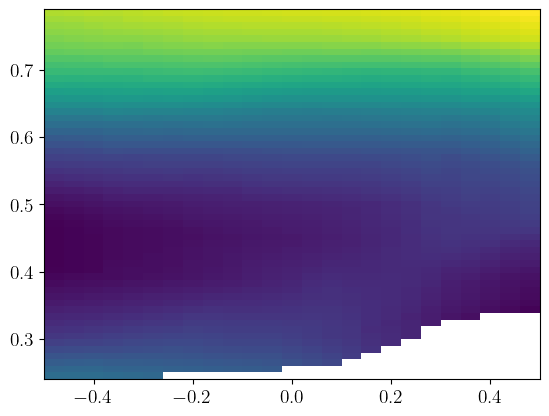

In [122]:
plt.imshow(z_grid, aspect='auto', origin='lower', extent=[metallicities.min(), metallicities.max(), masses.min(), masses.max()]);

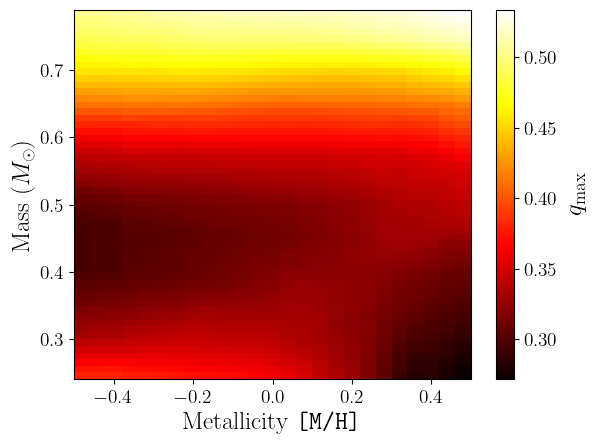

In [120]:
plt.imshow(Z_filled, aspect='auto', origin='lower', cmap="hot", extent=[metallicities.min(), metallicities.max(), masses.min(), masses.max()])
plt.colorbar(label=r"$q_\text{max}$");
plt.xlabel(r'Metallicity \texttt{[M/H]}');
plt.ylabel(r'Mass ($M_\odot$)');

In [123]:
final_table = Table.read('./data/combined_catalogue_23_04_26.fits', format='fits')

In [129]:
q_cutoffs = get_mass_ratio(final_table["mass_single"], final_table["mh_single"])
q_cutoffs_zero = get_mass_ratio(final_table["mass_single"], np.zeros(len(final_table)))

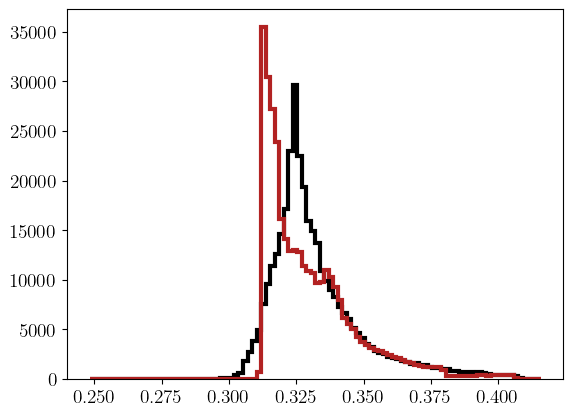

In [131]:
tbins = plt.hist(q_cutoffs, bins=100, **hist_defaults);
plt.hist(q_cutoffs_zero, bins=tbins[1], **hist_defaults);

In [ ]:
def generate_q_cutoffs(catalogue, q_cutoff_csv, mh="-0.0"):
    # rewrite to interpolate metallicity and mass somehow!!
    ms, qs = q_cutoff_csv["Mini"], q_cutoff_csv[mh]
    catalogue["q_max"] = np.interp(catalogue["mass_single"], ms, qs)

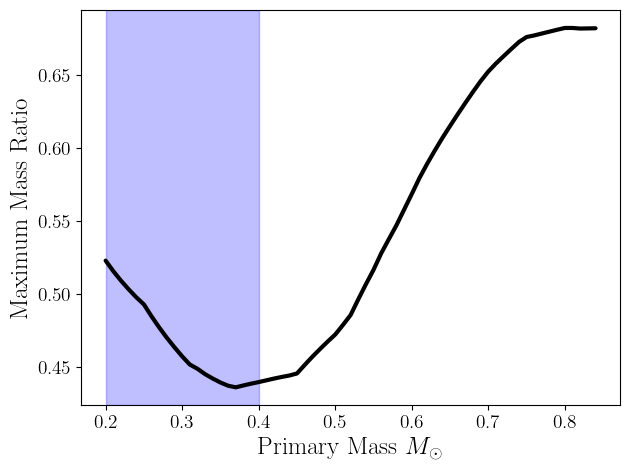

In [ ]:
massratios = pd.read_csv("./data/mass_ratio_threshold_table_01.csv", delimiter=",")
plt.plot(massratios["Mini"], massratios["-0.0"], c="k", lw=3, solid_capstyle='round');
#plt.scatter(massratios["Mini"], massratios["-0.0"], s=10, c="k");
plt.axvspan(0.2, 0.4, alpha=0.25, color="blue");
plt.xlabel(r"Primary Mass $M_\odot$");
plt.ylabel(r"Maximum Mass Ratio");
plt.tight_layout()
plt.savefig("./plots/MassRatioCutoff.pdf", dpi=800);

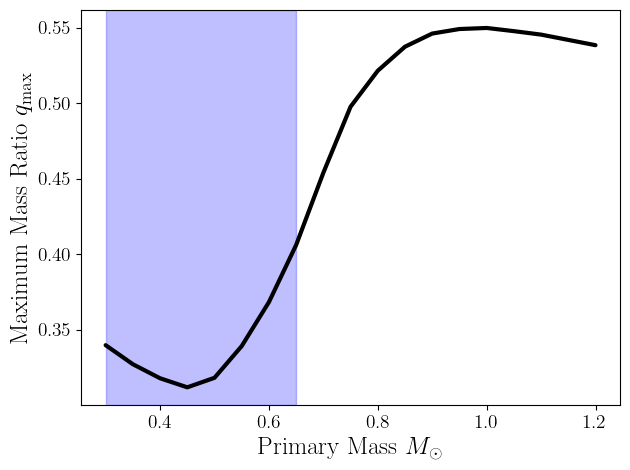

In [3]:
massratios = pd.read_csv("./data/mass_ratio_threshold_table.csv", delimiter=",")
plt.plot(massratios["Mini"], massratios["-0.0"], c="k", lw=3, solid_capstyle='round');
#plt.scatter(massratios["Mini"], massratios["-0.0"], s=10, c="k");
plt.axvspan(0.3, 0.65, alpha=0.25, color="blue");
plt.xlabel(r"Primary Mass $M_\odot$");
plt.ylabel(r"Maximum Mass Ratio $q_\text{max}$");
plt.tight_layout()
plt.savefig("./plots/MassRatioCutoff.png", dpi=800);

## Flux ratio cutoff

In [143]:
import utils.GaiamockWrapperLite as gw
import SyntheticData as sd

In [144]:
c_funcs = gw.generate_cfuncs()
def calculate_ruwe(df, period, q, ecc, fs = np.logspace(-3,-0.3,100)):
    inc = sd.random_inc()
    omega, Omega = sd.random_angle(), sd.random_angle()
    Tp = sd.random_Tp()
    
    t, t_mod = gw.generate_scanning_times(df["ra"], df["dec"])
    ruwes = np.zeros(len(fs))
    for j, f in enumerate(fs):
        _, ruwe = gw.rapid_solution_type(period, q, df["parallax"], df["mass_single"], df["phot_g_mean_mag"],
                                     f, ecc, inc, omega, Omega, Tp, df["ra"], df["dec"], df["pmra"], df["pmdec"], t=t, t_mod=t_mod, skip_full=True, return_ruwe=True, c_funcs=c_funcs)
        ruwes[j] = ruwe
    return ruwes

def calculate_soltype(df, period, q, ecc, f):
    inc = sd.random_inc()
    omega, Omega = sd.random_angle(), sd.random_angle()
    Tp = sd.random_Tp()
    
    t, t_mod = gw.generate_scanning_times(df["ra"], df["dec"])
    soltype = gw.rapid_solution_type(period, q, df["parallax"], df["mass_single"], df["phot_g_mean_mag"],
                                f, ecc, inc, omega, Omega, Tp, df["ra"], df["dec"], df["pmra"], df["pmdec"], t=t, t_mod=t_mod, c_funcs=c_funcs)
    return soltype

def calculate_all(df, period, q, ecc, fs=np.logspace(-3,-0.3,100), fcut=0.1):
    ind_1 = np.argmin(abs(fs - fcut))
    
    inc = sd.random_inc()
    omega, Omega = sd.random_angle(), sd.random_angle()
    Tp = sd.random_Tp()
    
    t, t_mod = gw.generate_scanning_times(df["ra"], df["dec"])
    ruwes = np.zeros(len(fs))
    sol0 = 0
    sol1 = 0
    for j, f in enumerate(fs):
        soltype, ruwe = gw.rapid_solution_type(period, q, df["parallax"], df["mass_single"], df["phot_g_mean_mag"],
                                     f, ecc, inc, omega, Omega, Tp, df["ra"], df["dec"], df["pmra"], df["pmdec"], t=t, t_mod=t_mod, skip_full=True, return_ruwe=True, c_funcs=c_funcs)
        if j == 0:
            sol0 = soltype
        elif j == ind_1:
            sol1 = soltype
        ruwes[j] = ruwe
    return ruwes, sol0, sol1

In [145]:
object_count = 1000
f_count = 100
fs = np.logspace(-3,-0.3,f_count)
ruwes = np.zeros((object_count,f_count))
sols_0 = np.zeros(object_count)
sols_1 = np.zeros(object_count)

In [146]:
object_set = np.random.choice(final_catalogue, object_count)
ps, qs, es = 10**(np.random.uniform(2,6, object_count)), np.random.uniform(0.3,0.5, object_count), np.random.uniform(0,1, object_count)
for i in tqdm(range(object_count)):
    ruwes[i] = calculate_ruwe(object_set[i], ps[i], qs[i], es[i], fs=fs)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [182]:
object_set = np.random.choice(final_catalogue, object_count)
ps, qs, es = 10**(np.random.uniform(2,6, object_count)), np.random.uniform(0.3,0.5, object_count), np.random.uniform(0,1, object_count)
for i in tqdm(range(object_count)):
    ruwes[i], sols_0[i], sols_1[i] = calculate_all(object_set[i], ps[i], qs[i], es[i], fs=fs)

  0%|          | 0/1000 [00:00<?, ?it/s]

(array([544.,   0.,   0.,   0.,   0., 443.,   0.,  11.,   0.,   2.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

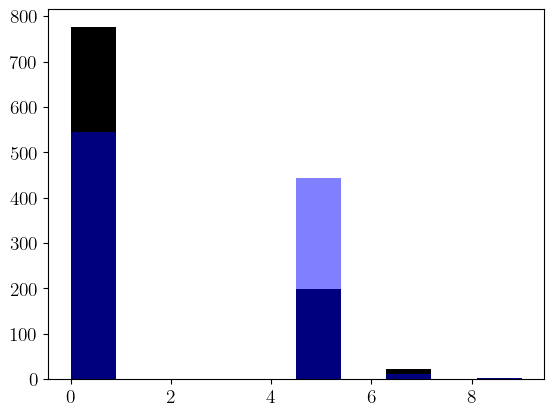

In [186]:
plt.hist(sols_0)
plt.hist(sols_1, color="blue", alpha=0.5)

In [190]:
object_set = np.random.choice(final_catalogue, object_count)
ps, qs, es = 10**(np.random.uniform(2,6, object_count)), np.random.uniform(0.3,0.5, object_count), np.random.uniform(0,1, object_count)
for i in tqdm(range(object_count)):
    ruwes[i], sols_0[i], sols_1[i] = calculate_all(object_set[i], ps[i], qs[i], es[i], fs=fs, fcut=10**(-1.5))

  0%|          | 0/1000 [00:00<?, ?it/s]

(array([655.,   0.,   0.,   0.,   0., 322.,   0.,  21.,   0.,   2.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

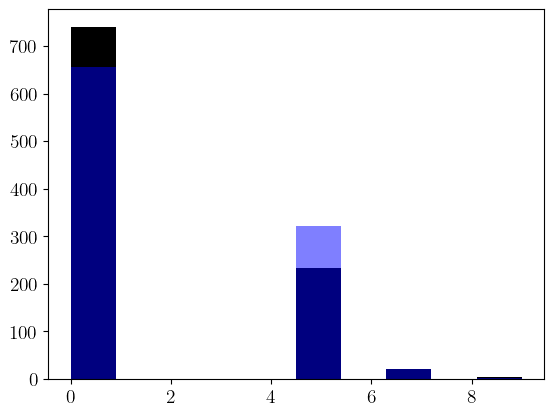

In [191]:
plt.hist(sols_0)
plt.hist(sols_1, color="blue", alpha=0.5)

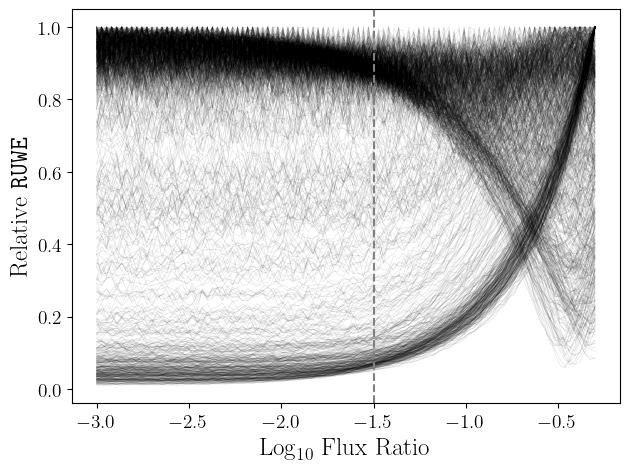

In [148]:
for i in range(object_count):
    plt.plot(np.log10(fs), ruwes[i]/np.max(ruwes[i]), lw=0.5, alpha=0.1);
    
#plt.axvline(x=-1  , c="red", linestyle="--");    
plt.axvline(x=-1.5, c="grey", linestyle="--");
plt.xlabel(r"$\text{Log}_{10}$ Flux Ratio");
plt.ylabel(r"Relative \texttt{RUWE}");
plt.tight_layout()
plt.savefig("./plots/fluxratiocutoff.jpg", dpi=400)

5
-0.22460542151672544


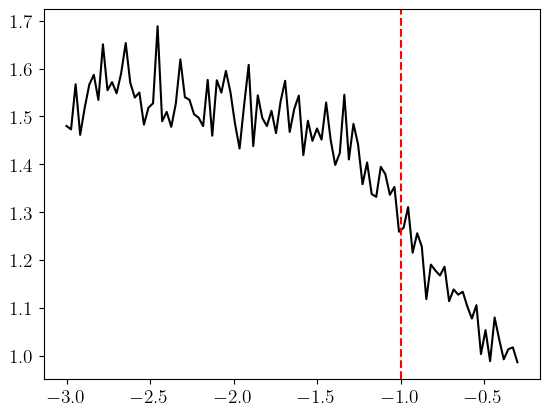

In [174]:
i += 1
print(i)
plt.plot(np.log10(fs), ruwes[i]);
plt.axvline(x=-1  , c="red", linestyle="--");    
ruw = np.interp(0.1, fs, ruwes[i])
avg = np.mean(ruwes[i][:25]) # average over the flat part at the beginning
print((ruw-avg)/ruw) 

In [162]:
errs = []
stds = []
for i in range(object_count):
    ruw = np.interp(0.1, fs, ruwes[i])
    avg = np.mean(ruwes[i][:25]) # average over the flat part at the beginning
    stds.append(np.std(ruwes[i][:25]))
    errs.append((ruw-avg)/ruw) 

In [161]:
np.mean(errs)

np.float64(0.12294995768856709)

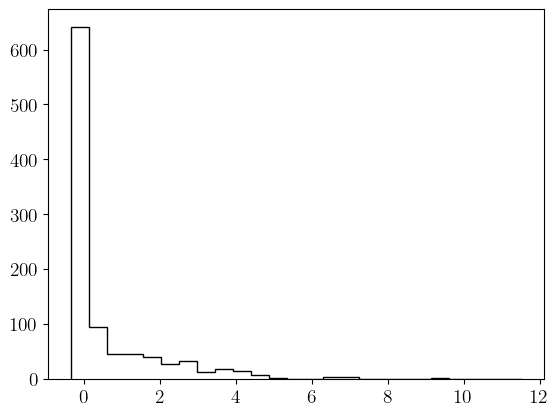

In [158]:
plt.hist(errs, histtype="step", bins=25);